# EMG + Motion-Capture Dataset Exploration

These are **XDF (Lab Streaming Layer)** recordings under `data/`, named `Iwami-{session}-{trial}.xdf`.
Each file holds **two time-synchronized streams**:

| Stream | Device | Channels | Nominal rate | Notes |
|--------|--------|----------|--------------|-------|
| **EMG**   | National Instruments USB-6225 | 28 | 2000 Hz | raw analog volts, unlabeled channels |
| **Mocap** | OptiTrack | 76 | 240 Hz (≈120 Hz effective) | markers + rigid-body pose, meters |

This notebook inventories the files, breaks down the stream structure, and plots sample
time-series from both streams.

In [1]:
import glob, os, logging, warnings
import numpy as np
import matplotlib.pyplot as plt
import pyxdf

# pyxdf is chatty about the OptiTrack nominal-vs-effective rate mismatch; quiet it down.
warnings.filterwarnings('ignore')
logging.getLogger('pyxdf').setLevel(logging.ERROR)

DATA_DIR = 'data'
files = sorted(glob.glob(os.path.join(DATA_DIR, '*.xdf')))
print(f'{len(files)} XDF files found:')
for f in files:
    print(f'  {os.path.basename(f):16} {os.path.getsize(f)/1e6:6.1f} MB')

13 XDF files found:
  Iwami-1-1.xdf       5.3 MB
  Iwami-1-2.xdf       5.3 MB
  Iwami-1-3.xdf       4.5 MB
  Iwami-1-4.xdf       6.4 MB
  Iwami-1-5.xdf       5.3 MB
  Iwami-2-1.xdf       6.1 MB
  Iwami-2-2.xdf       5.8 MB
  Iwami-2-3.xdf       6.3 MB
  Iwami-2-4.xdf       6.8 MB
  Iwami-2-5.xdf       6.1 MB
  Iwami-3-1.xdf      18.8 MB
  Iwami-3-2.xdf      18.2 MB
  Iwami-4-1.xdf      10.7 MB


## 1. File inventory

Load every file and tabulate the two streams: channel count, nominal vs. *effective* sampling
rate (derived from the timestamps), sample count, and duration. The effective rate is what you
should trust for any rate-dependent processing.

In [2]:
def stream_summary(s):
    info = s['info']
    ts = s['time_stamps']
    dur = ts[-1] - ts[0] if len(ts) > 1 else 0.0
    eff = (len(ts) - 1) / dur if dur else 0.0
    return {
        'name': info['name'][0],
        'type': info['type'][0],
        'n_channels': int(info['channel_count'][0]),
        'nominal_hz': float(info['nominal_srate'][0]),
        'effective_hz': eff,
        'n_samples': len(ts),
        'duration_s': dur,
    }

rows = []
for f in files:
    streams, _ = pyxdf.load_xdf(f)
    for s in streams:
        d = stream_summary(s)
        d['file'] = os.path.basename(f)
        rows.append(d)

# Pretty-print without requiring pandas.
hdr = f"{'file':16} {'type':6} {'ch':>3} {'nom Hz':>7} {'eff Hz':>7} {'samples':>8} {'dur s':>7}"
print(hdr)
print('-' * len(hdr))
for r in rows:
    print(f"{r['file']:16} {r['type']:6} {r['n_channels']:3d} "
          f"{r['nominal_hz']:7.0f} {r['effective_hz']:7.0f} "
          f"{r['n_samples']:8d} {r['duration_s']:7.1f}")

file             type    ch  nom Hz  eff Hz  samples   dur s
------------------------------------------------------------
Iwami-1-1.xdf    Mocap   76     240     120     2345    19.5
Iwami-1-1.xdf    EMG     28    2000    1998    40000    20.0
Iwami-1-2.xdf    EMG     28    2000    1999    40000    20.0
Iwami-1-2.xdf    Mocap   76     240     120     2523    21.0
Iwami-1-3.xdf    Mocap   76     240     120     2049    17.1
Iwami-1-3.xdf    EMG     28    2000    2001    34000    17.0
Iwami-1-4.xdf    EMG     28    2000    2000    48000    24.0
Iwami-1-4.xdf    Mocap   76     240     120     2991    24.9
Iwami-1-5.xdf    Mocap   76     240     120     2345    19.5
Iwami-1-5.xdf    EMG     28    2000    1998    40000    20.0
Iwami-2-1.xdf    Mocap   76     240     120     2705    22.5
Iwami-2-1.xdf    EMG     28    2000    2001    46000    23.0
Iwami-2-2.xdf    EMG     28    2000    1999    44000    22.0
Iwami-2-2.xdf    Mocap   76     240     120     2644    22.0
Iwami-2-3.xdf    Mocap  

## 2. Look inside one recording

Pick a representative file and pull out the EMG and Mocap streams for closer inspection.

In [3]:
SAMPLE_FILE = os.path.join(DATA_DIR, 'Iwami-1-1.xdf')
streams, file_header = pyxdf.load_xdf(SAMPLE_FILE)
by_type = {s['info']['type'][0]: s for s in streams}
emg, mocap = by_type['EMG'], by_type['Mocap']

emg_data = np.asarray(emg['time_series'])      # (n_samples, 28)
emg_t = np.asarray(emg['time_stamps'])
mocap_data = np.asarray(mocap['time_series'])  # (n_samples, 76)
mocap_t = np.asarray(mocap['time_stamps'])

print('File:', os.path.basename(SAMPLE_FILE))
print('EMG   :', emg_data.shape, 'dtype', emg_data.dtype)
print('Mocap :', mocap_data.shape, 'dtype', mocap_data.dtype)

# Both streams share the same LSL clock; report their relative start offset.
print(f'\nEMG   t0={emg_t[0]:.3f}  t1={emg_t[-1]:.3f}')
print(f'Mocap t0={mocap_t[0]:.3f}  t1={mocap_t[-1]:.3f}')
print(f'Mocap starts {mocap_t[0] - emg_t[0]:+.3f}s relative to EMG')

# Use a common t=0 for plotting (start of the EMG stream).
t0 = emg_t[0]
emg_t -= t0
mocap_t -= t0

File: Iwami-1-1.xdf
EMG   : (40000, 28) dtype float32
Mocap : (2345, 76) dtype float32

EMG   t0=3119056.994  t1=3119077.010
Mocap t0=3119057.445  t1=3119076.985
Mocap starts +0.451s relative to EMG


### Mocap channel layout

The OptiTrack stream is the only one carrying per-channel labels: raw marker positions,
per-bone markers for two rigid bodies, then each rigid body's pose (position X/Y/Z,
quaternion A/B/C/D, confidence).

In [4]:
def channel_labels(stream):
    try:
        chs = stream['info']['desc'][0]['channels'][0]['channel']
        return [c['label'][0] for c in chs]
    except (TypeError, KeyError, IndexError):
        return None

mocap_labels = channel_labels(mocap)
print(f'Mocap: {len(mocap_labels)} labeled channels')
for i, lab in enumerate(mocap_labels):
    print(f'  [{i:2d}] {lab}')

emg_labels = channel_labels(emg)
print(f'\nEMG channel labels: {emg_labels}  '
      '(unlabeled — 28 raw analog channels, index 0–27)')

Mocap: 76 labeled channels
  [ 0] Marker1_X
  [ 1] Marker1_Y
  [ 2] Marker1_Z
  [ 3] Marker2_X
  [ 4] Marker2_Y
  [ 5] Marker2_Z
  [ 6] Marker3_X
  [ 7] Marker3_Y
  [ 8] Marker3_Z
  [ 9] Marker4_X
  [10] Marker4_Y
  [11] Marker4_Z
  [12] Marker1_X
  [13] Marker1_Y
  [14] Marker1_Z
  [15] Marker2_X
  [16] Marker2_Y
  [17] Marker2_Z
  [18] Marker3_X
  [19] Marker3_Y
  [20] Marker3_Z
  [21] Marker4_X
  [22] Marker4_Y
  [23] Marker4_Z
  [24] Marker5_X
  [25] Marker5_Y
  [26] Marker5_Z
  [27] Marker6_X
  [28] Marker6_Y
  [29] Marker6_Z
  [30] Rigid Body 1_1_X
  [31] Rigid Body 1_1_Y
  [32] Rigid Body 1_1_Z
  [33] Rigid Body 1_2_X
  [34] Rigid Body 1_2_Y
  [35] Rigid Body 1_2_Z
  [36] Rigid Body 1_3_X
  [37] Rigid Body 1_3_Y
  [38] Rigid Body 1_3_Z
  [39] Rigid Body 1_4_X
  [40] Rigid Body 1_4_Y
  [41] Rigid Body 1_4_Z
  [42] Rigid Body 2_1_X
  [43] Rigid Body 2_1_Y
  [44] Rigid Body 2_1_Z
  [45] Rigid Body 2_2_X
  [46] Rigid Body 2_2_Y
  [47] Rigid Body 2_2_Z
  [48] Rigid Body 2_3_X
  [49] 

## 3. EMG sample time-series

EMG channels carry very different amounts of activity (per-channel std spans ~0.002–0.14 V).
Rank channels by standard deviation and plot the most active ones.

EMG per-channel std (V):
  ch 0: 0.0086
  ch 1: 0.0113
  ch 2: 0.0118
  ch 3: 0.0102
  ch 4: 0.0063
  ch 5: 0.0113
  ch 6: 0.0156
  ch 7: 0.0083
  ch 8: 0.0303
  ch 9: 0.0097
  ch10: 0.0170
  ch11: 0.0084
  ch12: 0.1393
  ch13: 0.0096
  ch14: 0.0168
  ch15: 0.0153
  ch16: 0.0024
  ch17: 0.0123
  ch18: 0.0071
  ch19: 0.0087
  ch20: 0.0325
  ch21: 0.0091
  ch22: 0.0168
  ch23: 0.0101
  ch24: 0.0096
  ch25: 0.0081
  ch26: 0.0116
  ch27: 0.0099


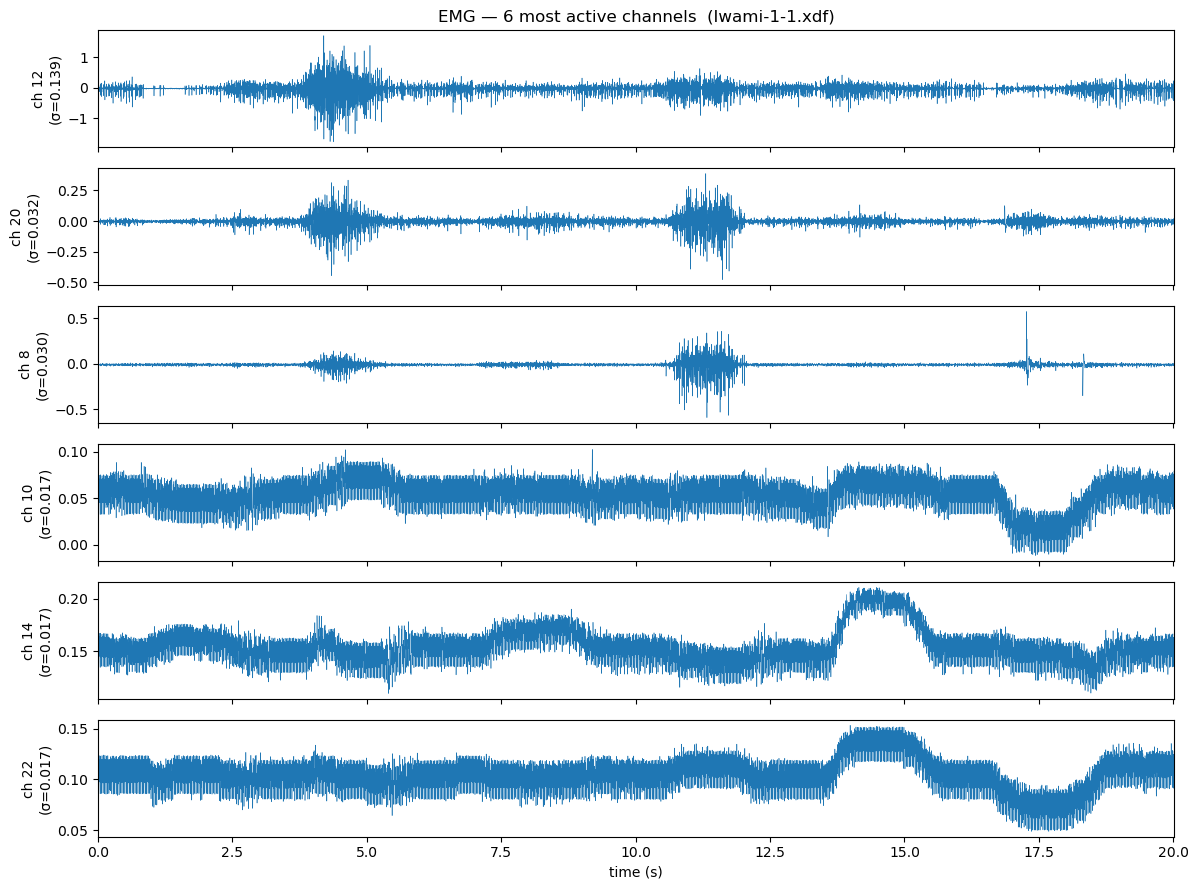

In [5]:
ch_std = emg_data.std(axis=0)
order = np.argsort(ch_std)[::-1]
print('EMG per-channel std (V):')
for ch in range(emg_data.shape[1]):
    print(f'  ch{ch:2d}: {ch_std[ch]:.4f}')

top = order[:6]
fig, axes = plt.subplots(len(top), 1, figsize=(12, 9), sharex=True)
for ax, ch in zip(axes, top):
    ax.plot(emg_t, emg_data[:, ch], lw=0.4)
    ax.set_ylabel(f'ch {ch}\n(σ={ch_std[ch]:.3f})')
    ax.margins(x=0)
axes[0].set_title(f'EMG — 6 most active channels  ({os.path.basename(SAMPLE_FILE)})')
axes[-1].set_xlabel('time (s)')
fig.tight_layout()
plt.show()

### Zoom in on a 1-second window

At 2000 Hz the full trace looks like a solid band. Zoom in to see the raw EMG waveform
of the single most active channel.

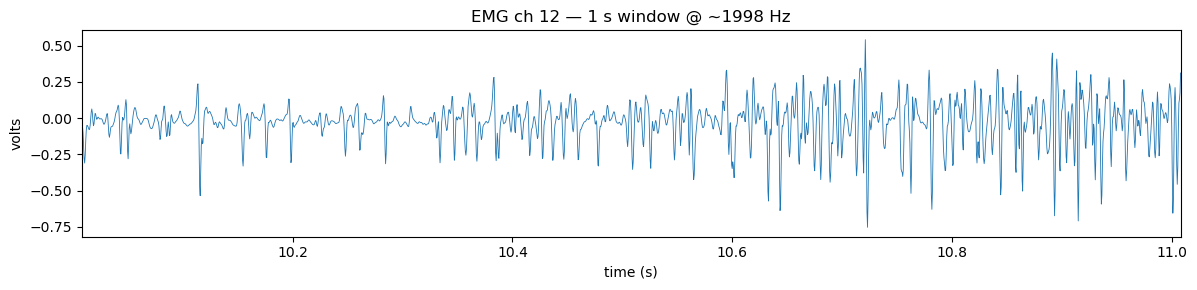

In [6]:
ch = int(order[0])
fs = (len(emg_t) - 1) / (emg_t[-1] - emg_t[0])
start_s = emg_t[-1] / 2            # grab a window mid-recording
mask = (emg_t >= start_s) & (emg_t < start_s + 1.0)

plt.figure(figsize=(12, 3))
plt.plot(emg_t[mask], emg_data[mask, ch], lw=0.6)
plt.title(f'EMG ch {ch} — 1 s window @ ~{fs:.0f} Hz')
plt.xlabel('time (s)'); plt.ylabel('volts'); plt.margins(x=0)
plt.tight_layout(); plt.show()

## 4. Mocap sample time-series

Plot the position (X/Y/Z, in meters) of the two rigid bodies over the recording.

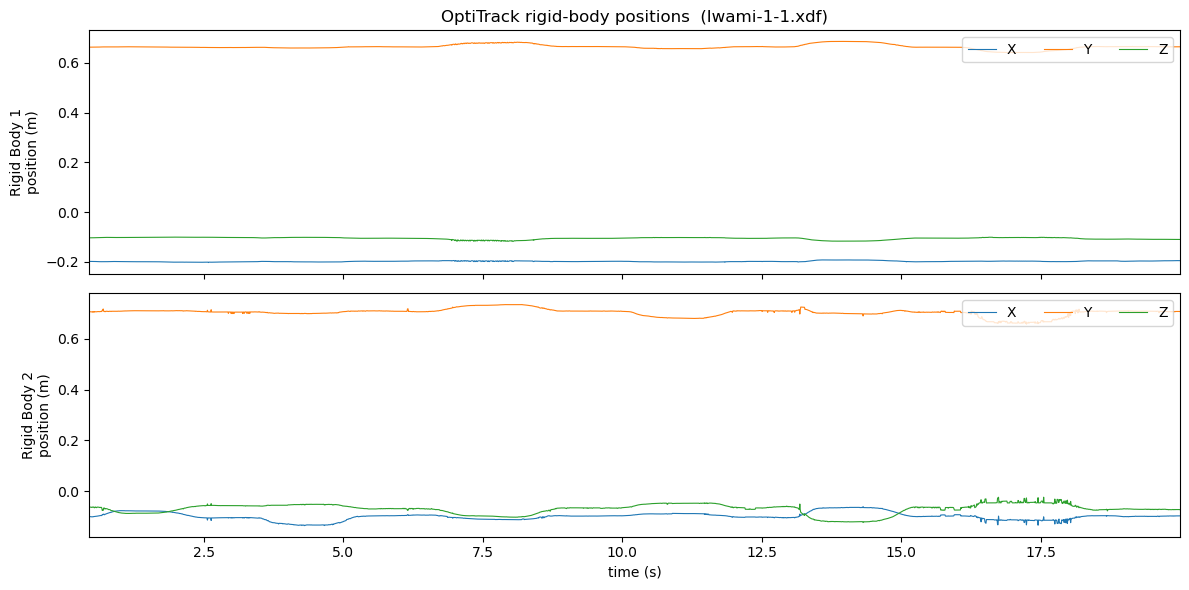

In [7]:
# Find the rigid-body position channels by label (exclude quaternion / confidence).
def find_idx(labels, name):
    return {axis: labels.index(f'{name}_{axis}') for axis in ('X', 'Y', 'Z')}

rb1 = find_idx(mocap_labels, 'Rigid Body 1')
rb2 = find_idx(mocap_labels, 'Rigid Body 2')

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
for ax, (name, idx) in zip(axes, [('Rigid Body 1', rb1), ('Rigid Body 2', rb2)]):
    for axis, col in idx.items():
        ax.plot(mocap_t, mocap_data[:, col], lw=0.8, label=axis)
    ax.set_ylabel(f'{name}\nposition (m)')
    ax.legend(loc='upper right', ncol=3); ax.margins(x=0)
axes[0].set_title(f'OptiTrack rigid-body positions  ({os.path.basename(SAMPLE_FILE)})')
axes[-1].set_xlabel('time (s)')
fig.tight_layout(); plt.show()

### 3-D trajectory of the markers

A quick 3-D view of where Rigid Body 1 travels during the trial.

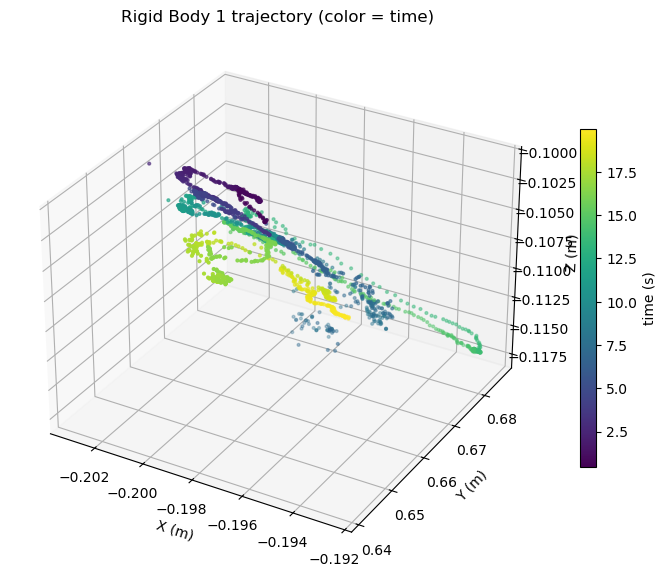

In [8]:
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection='3d')
x, y, z = (mocap_data[:, rb1['X']], mocap_data[:, rb1['Y']], mocap_data[:, rb1['Z']])
sc = ax.scatter(x, y, z, c=mocap_t, cmap='viridis', s=4)
ax.set_xlabel('X (m)'); ax.set_ylabel('Y (m)'); ax.set_zlabel('Z (m)')
ax.set_title('Rigid Body 1 trajectory (color = time)')
fig.colorbar(sc, ax=ax, shrink=0.6, label='time (s)')
plt.tight_layout(); plt.show()

## 5. EMG and Mocap on a common timeline

Overlay an active EMG channel with a rigid-body position so the two streams (2000 Hz vs.
~120 Hz) can be compared on the same time axis — the starting point for any EMG↔motion
alignment / resampling step in a downstream pipeline.

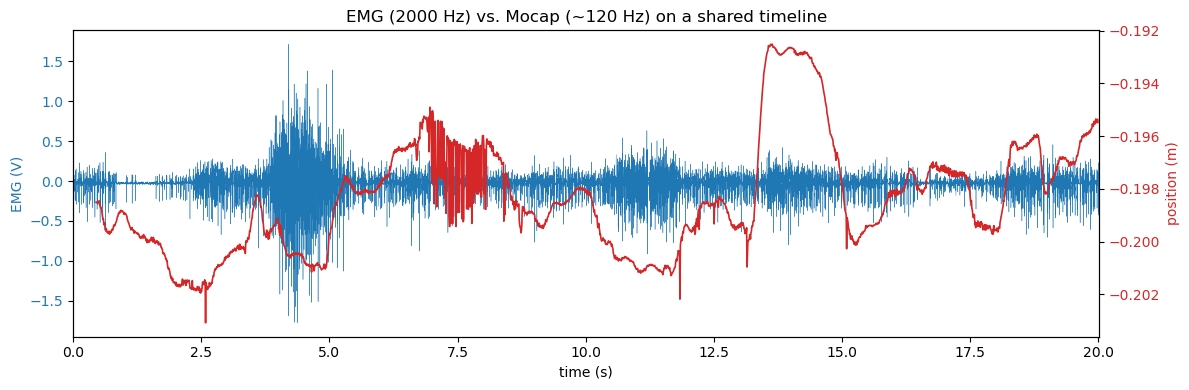

In [9]:
fig, ax1 = plt.subplots(figsize=(12, 4))
ax1.plot(emg_t, emg_data[:, int(order[0])], lw=0.3, color='tab:blue',
         label=f'EMG ch {int(order[0])}')
ax1.set_xlabel('time (s)'); ax1.set_ylabel('EMG (V)', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue'); ax1.margins(x=0)

ax2 = ax1.twinx()
ax2.plot(mocap_t, mocap_data[:, rb1['X']], lw=1.2, color='tab:red',
         label='RB1 X position')
ax2.set_ylabel('position (m)', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

ax1.set_title('EMG (2000 Hz) vs. Mocap (~120 Hz) on a shared timeline')
fig.tight_layout(); plt.show()